In [1]:
# Import the libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import ParameterGrid

In [2]:
# Load the data
df = pd.read_csv('../data/credit_card_final.csv')

# Head
df.head()

,purchases_frequency,oneoff_share,cash_advance_ratio,oneoff_purchases_frequency,prc_full_payment,credit_limit,balance_frequency
0,-0.951520,-0.951750,-0.751907,-0.739894,-0.654221,-0.996401,-0.257893
1,-1.372104,-0.951750,1.596484,-0.739894,0.025487,0.604512,0.150106
2,-1.161813,1.427420,-0.751907,-0.480047,-0.654221,-0.943038,0.558104
3,1.151393,1.196456,-0.751907,2.378288,2.404469,2.338834,0.558104
4,1.151393,-0.951750,-0.751907,-0.739894,-0.654221,-0.649537,0.558104


In [13]:
# Evaluate kmeans
def evaluate_kmeans(X, k_range, n_repeats = 5):
    results = []
    for k in k_range:
        inertias = []
        sil_scores = []
        db_scores = []
        for _ in range(n_repeats):
            km = KMeans(n_clusters = k, random_state = None, n_init = 10)
            labels = km.fit_predict(X)
            inertias.append(km.inertia_)
            if k > 1:
                sil_scores.append(silhouette_score(X, labels))
                db_scores.append(davies_bouldin_score(X, labels))
            
            avg_inertia = np.mean(inertias)
            avg_sil = np.mean(sil_scores) if k > 1 else 0
            avg_db = np.mean(db_scores) if k > 1 else np.inf

            results.append({
                'k': k,
                'inertia': avg_inertia,
                'silhouette': avg_sil,
                'davies_bouldin': avg_db
            })
    return pd.DataFrame(results)

In [14]:
# Start clustering with at least 2
X = df.values

k_range = range(2, 11)
kmeans_results = evaluate_kmeans(X, k_range, n_repeats = 5)
print(kmeans_results)

     k       inertia  silhouette  davies_bouldin
0    2  15385.062749    0.417840        0.928579
1    2  15385.055920    0.417840        0.928579
2    2  15385.059737    0.417840        0.928579
3    2  15385.057076    0.417840        0.928579
4    2  15385.059135    0.417840        0.928579
5    3   9263.710443    0.474900        0.890788
6    3   9263.710443    0.474900        0.890788
7    3   9263.710443    0.474900        0.890788
8    3   9263.710443    0.474900        0.890788
9    3   9263.711600    0.474892        0.890753
10   4   5597.845039    0.554212        0.732402
11   4   5597.846477    0.554212        0.732402
12   4   5597.844111    0.554202        0.732588
13   4   5597.843436    0.554195        0.732713
14   4   5597.843032    0.554191        0.732788
15   5   4565.041177    0.565885        0.712906
16   5   4565.041177    0.565885        0.712906
17   5   4565.041177    0.565885        0.712906
18   5   4565.041177    0.565885        0.712906
19   5   4565.040752

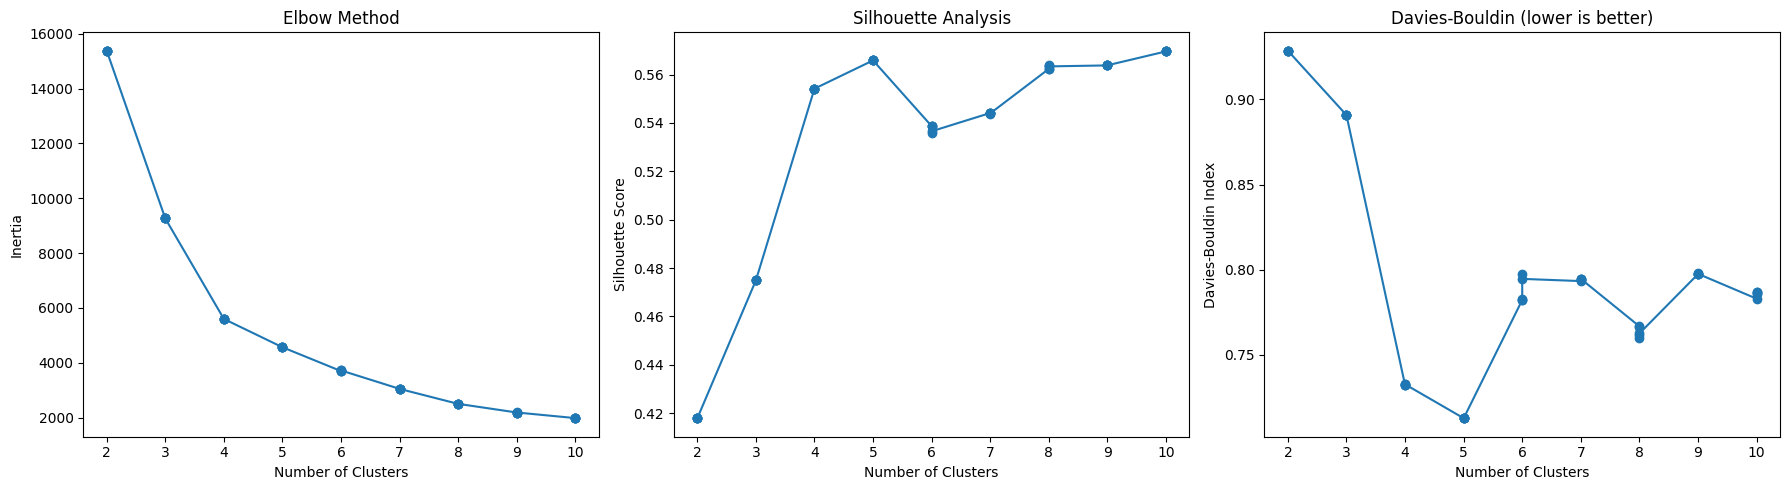

In [15]:
# Plot the metrics to pick the best
fig, axes = plt.subplots(1, 3, figsize = (18, 5))

axes[0].plot(kmeans_results['k'], kmeans_results['inertia'], marker = 'o')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(kmeans_results['k'], kmeans_results['silhouette'], marker = 'o')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis')

axes[2].plot(kmeans_results['k'], kmeans_results['davies_bouldin'], marker = 'o')
axes[2].set_xlabel('Number of Clusters')
axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Davies-Bouldin (lower is better)')

plt.tight_layout()
plt.show()